<a href="https://colab.research.google.com/github/KIRANVVIT/CODE-FOBE-PROBLEM-STATEMENTS/blob/main/week16_session1_assign_kiran.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 16, Session 1, July 11, Saturday**

Problem statement1. Imagine you are a data analyst or a developer who needs to collect job listings from the Indeed job scraper page provided by Octoparse.

Before extracting data, you must ensure that:

* ✅ The website is accessible (i.e., it's not down).
* ✅ The server is responding correctly (returns status code 200).
* ✅ You are not blocked (some websites block automated scraping).

By checking the status code, you can confirm whether your request was successful or if there is an issue preventing access.

We need to send a request to the website and check its response status code to confirm that the webpage is available.

**here is the link from which u have to scrape data**

https://www.octoparse.com/template/indeed-job-listing-scraper

**Expected Output**

Status Code: 200

In [3]:
import requests

# URL of the Indeed job scraper template on Octoparse
url = "https://www.octoparse.com/template/indeed-job-listing-scraper"

# Send a GET request to fetch the webpage
response = requests.get(url)

# Print the status code to check if the request was successful
print("Status Code:", response.status_code)


Status Code: 200


Problem Statement2:
Now that we have confirmed that the Indeed job listing page is accessible, the next step is to parse the HTML content.

Web pages are written in HTML (HyperText Markup Language), which consists of various tags and elements. However, when we fetch the page using requests.get(), the response is in raw HTML format, making it difficult to extract specific information directly.

1️⃣  Parse the raw HTML using BeautifulSoup.

2️⃣ Print a small portion of the HTML (500 characters) to inspect the page structure.

Expected Output

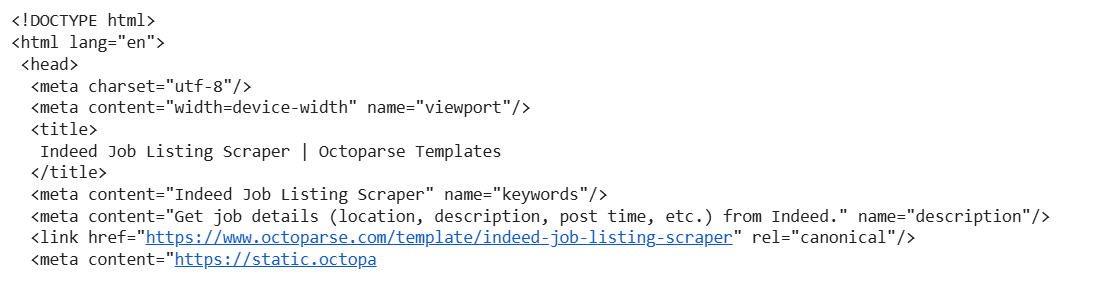

In [4]:
from bs4 import BeautifulSoup
# Step 2: Parse the HTML content with BeautifulSoup
soup = BeautifulSoup(response.text, "html.parser")

# Step 3: Print the first 500 characters of the HTML to inspect structure
print(soup.prettify()[:500])

<!DOCTYPE html>
<html lang="en">
 <head>
  <meta charset="utf-8"/>
  <meta content="width=device-width" name="viewport"/>
  <script type="application/ld+json">
   {"@context":"https://schema.org","@graph":[{"@type":"Organization","@id":"https://www.octoparse.com/#organization","name":"Octoparse","legalName":"Octopus Data Inc.","url":"https://www.octoparse.com","logo":{"@type":"ImageObject","url":"https://www.octoparse.com/static/logo.svg"},"description":"Octoparse is a no-code web scraping platf


Problem Statement3:
Now that we have successfully fetched and parsed the HTML content, the next step is to find the table containing the job listings.

On many websites, data is organized in tables using the <table> tag. To extract job listings, we first need to identify and locate the correct table within the webpage.

1️⃣ Use BeautifulSoup to search for the < table > tag in the parsed HTML.

2️⃣ Print a confirmation message to check if the table is found.

Expected Output

Table Found: True

or if no table is found:

Table Found: False

In [5]:
# Step 3: Locate the job listings table
table = soup.find("table")

# Step : Print confirmation if the table is found
print("Table Found:", bool(table))

Table Found: True


Problem Statement4:
On inspecting the Indeed job listings page, you will find that all column names (headers) are stored inside <th> (table header) tags within the <table> element.

Each job listing is organized in columns, with headers such as:

* ✅ Country
* ✅ Search Keyword
* ✅ Search Location
* ✅ Job Title
* ✅ Job Detail Link
* ✅ Short Description
* ✅ Company Name
* ✅ Location
* ✅ Salary


Since we do not need the last two columns (Post Date (Original) and Post Date (Cleaned)), we will extract and print only the first 9 columns.

1️⃣ Identify and extract all headers inside < th > tags.
2️⃣ Print the column names to confirm extraction.
3️⃣ Exclude the last two columns before storing the headers.

Expected Output

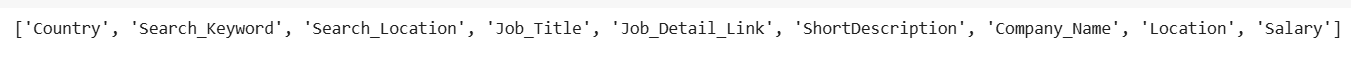

In [6]:
# Extract all table headers (column names)
headers = [th.get_text(strip=True) for th in table.find_all("th")]

# Remove the last 2 columns
headers = headers[:-2]

# Print the extracted column names
print(headers)


['Country', 'Search_Keyword', 'Search_Location', 'Job_Title', 'Job_Detail_Link', 'ShortDescription', 'Company_Name', 'Location', 'Salary']


Problem Statement5:
Now that we have confirmed the table structure and headers, the next step is to extract the first job listing from the table.

Each job listing is stored inside a <tr> (table row) tag. The first row usually contains headers, so we need to skip the first row and extract the first actual job listing from the second row onwards.

Each job listing contains multiple columns, including:
* ✅ Job Title
* ✅ Company Name
* ✅ Location
* ✅ Salary

In this problem, we will extract the first row of job data and print its details.

1️⃣ Find all rows in the table.
2️⃣ Skip the header row (first <tr>).
3️⃣ Extract the first job listing and print its details.

Expected Output

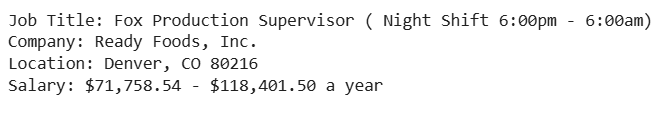



In [7]:
# Extract all table rows
rows = table.find_all("tr")

# Skip the first row (header) and select the first job listing
first_row = rows[1].find_all("td")  # Extract the second row (index 1)

# Extract job details from the first row
job_title = first_row[3].get_text(strip=True)
company = first_row[6].get_text(strip=True)
location = first_row[7].get_text(strip=True)
salary = first_row[8].get_text(strip=True)

# Print the first job listing details
print(f"Job Title: {job_title}")
print(f"Company: {company}")
print(f"Location: {location}")
print(f"Salary: {salary}")


Job Title: Fox Production Supervisor ( Night Shift 6:00pm - 6:00am)
Company: Ready Foods, Inc.
Location: Denver, CO 80216
Salary: $71,758.54 - $118,401.50 a year


Problem Statement6:
Now that we have successfully extracted the first job listing, the next step is to extract all job titles from the entire job listings table.

Each job title is stored in a specific column inside a <td> (table data) tag. By looping through all rows, we can extract only the job titles and print them.

This will help us:
✅ Extract all job titles from the Indeed job scraper table.
✅ Ensure that we are scraping data efficiently before moving forward.

1️⃣ Find all table rows in the job listings table.
2️⃣ Skip the header row and extract the Job Title column.
3️⃣ Store and print all job titles.

Expected Output

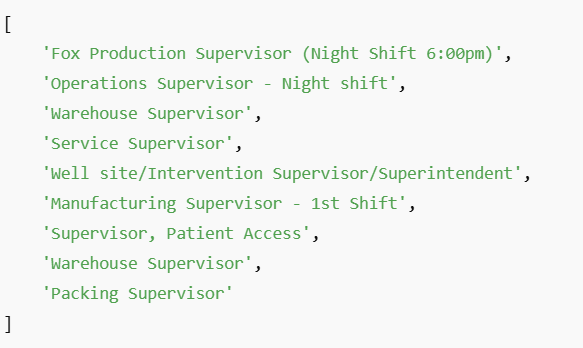



In [8]:
# Extract all table rows (excluding the header)
rows = table.find_all("tr")[1:]  # Skip the first row (header)

# Extract job titles from each row
job_titles = [row.find_all("td")[3].get_text(strip=True) for row in rows]

# Print all job titles
print(job_titles)


['Fox Production Supervisor ( Night Shift 6:00pm - 6:00am)', 'Operations Supervisor - Night shift', 'Warehouse Supervisor', 'Warehouse Supervisor', 'Service Supervisor', 'Well site/Intervention Supervisor/Superintendent - Contract', 'Manufacturing Supervisor - 1st Shift', 'Supervisor, Patient Access', 'Warehouse Supervisor', 'Packing Supervisor']


Problem Statement7:
Now that we have extracted all job titles, the next step is to extract job titles along with their respective company names from the job listings table.

Each job title and company name is stored in a specific column inside <td> (table data) tags within the table rows. By extracting both values together, we can get a clear understanding of which company is offering which job.

1️⃣ Find all table rows in the job listings table.
2️⃣ Skip the header row and extract the Job Title and Company Name columns.
3️⃣ Print them together in a structured format.

Expected Output

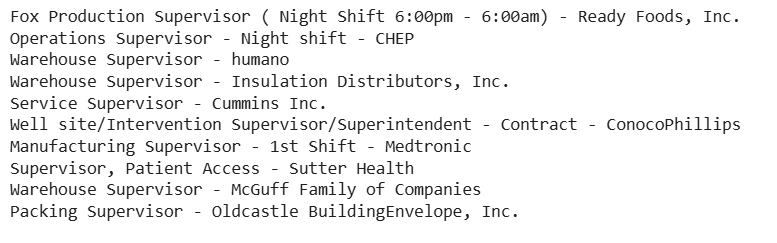

In [9]:
table = soup.find("table")
# Extract all table rows (excluding the header)
rows = table.find_all("tr")[1:]  # Skip the first row (header)

# Loop through each row and extract job titles with company names
for row in rows:
    cells = row.find_all("td")
    job_title = cells[3].get_text(strip=True)
    company_name = cells[6].get_text(strip=True)

    print(f"{job_title} - {company_name}")


Fox Production Supervisor ( Night Shift 6:00pm - 6:00am) - Ready Foods, Inc.
Operations Supervisor - Night shift - CHEP
Warehouse Supervisor - humano
Warehouse Supervisor - Insulation Distributors, Inc.
Service Supervisor - Cummins Inc.
Well site/Intervention Supervisor/Superintendent - Contract - ConocoPhillips
Manufacturing Supervisor - 1st Shift - Medtronic
Supervisor, Patient Access - Sutter Health
Warehouse Supervisor - McGuff Family of Companies
Packing Supervisor - Oldcastle BuildingEnvelope, Inc.


Problem Statement8:
Each job listing on Indeed's job scraper page contains a clickable link that directs users to the detailed job description page. This link is stored inside a specific column in the table under a <td> (table data) tag.

The job detail link is important because it allows users to:
✅ View more information about a job.
✅ Apply directly through the job listing page.
✅ Ensure the extracted job data is coming from a valid source.

Our goal is to extract the job detail link for each job listing and print them.

1️⃣ Find all table rows in the job listings table.
2️⃣ Skip the header row and extract the Job Detail Link column.
3️⃣ Print the extracted links.

Expected Output

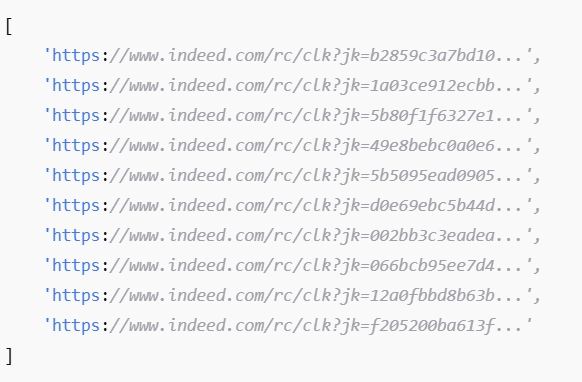

In [10]:
# Extract all table rows (excluding the header)
rows = table.find_all("tr")[1:]  # Skip the first row (header)

# Extract job detail links from each row
job_links = [row.find_all("td")[4].get_text(strip=True) for row in rows]

# Print all job detail links
print(job_links)


['https://www.indeed.com/rc/clk?jk=b2859c3a7bd10211&bb=WSV0JKw91-PIISrIAlyvGYw_kOFqPkTFBAwelsQfPSmenK1U3mfuhLWsv0zBLqApCngJ0nWX3A-5oJxtDfSAI1a6Fdy9_ze1qO7h9Pih_8QVjqF-SRIq_jfQkoLk-Ucg&xkcb=SoB167M35FSXZ5xOBR0LbzkdCdPP&fccid=9f22abda9adbceeb&vjs=3', 'https://www.indeed.com/rc/clk?jk=1a03ce912ecbb5bc&bb=WSV0JKw91-PIISrIAlyvGVmkw9Cn1Q1aMcemEUUHgWJ-LgTGyYWQfMIsTGqNyAYlkixwnkuWGZi4wkxcIEjsrOmR3UxIRc95iM1-CEGKg_h1zQ1lohbZ0u1_ua-PE8pW&xkcb=SoDB67M35FSXZ5xOBR0KbzkdCdPP&fccid=25ed7242fa1eb0a0&cmp=CHEP-USA&ti=Operations+Supervisor&vjs=3', 'https://www.indeed.com/rc/clk?jk=5b80f1f6327e10b5&bb=WSV0JKw91-PIISrIAlyvGTOaV1icfyfCu1_RKVDfaZaX194Rs-6Q-4tiJ_NDO7Ewt3CNdcRwnuPmJChcwcMlyKBIYUus6zGeeG4v99hPfDIGa1aI7RsuEunTiuRCnXuzmzBkd8TilcU%3D&xkcb=SoBc67M35FSXZ5xOBR0JbzkdCdPP&fccid=203cd175678da2c0&vjs=3', 'https://www.indeed.com/rc/clk?jk=49e8bebc0a0e605f&bb=WSV0JKw91-PIISrIAlyvGWAPLcKR-TyYmlPWhbDGe_bGWlgeWW7a1D1DU0dHsdU69YeFjKip_Zp4PI95Jmp0oTpnXk5KYiBcSaj8PLHLMlGDkbictNTWQTs_7S6-Ioxj&xkcb=SoDo67M35FSXZ5x

Problem Statement9:
Each job listing on Indeed's job scraper page contains salary information in a specific column. This salary information can be:
* ✅ A fixed salary range (e.g., "$60,000 - $75,000 a year").
* ✅ An hourly rate (e.g., "$25 - $35 an hour").
* ✅ Not provided (some listings do not display salary information).

1️⃣ Find all table rows in the job listings table.
2️⃣ Skip the header row and extract the Salary column.
3️⃣ Print the extracted salary information.

Expected Output

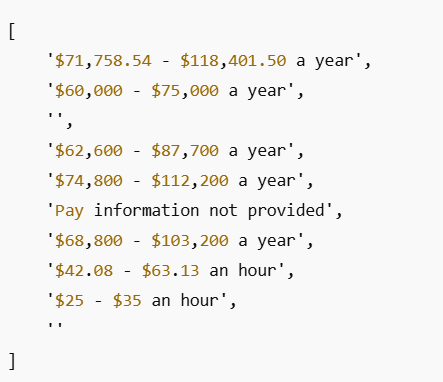

In [11]:
# Extract all table rows (excluding the header)
rows = table.find_all("tr")[1:]  # Skip the first row (header)

# Extract job salaries from each row
salaries = [row.find_all("td")[8].get_text(strip=True) for row in rows]

# Print all job salaries
print(salaries)


['$71,758.54 - $118,401.50 a year', '$60,000 - $75,000 a year', '', '$62,600 - $87,700 a year', '$74,800 - $112,200 a year', '', '$68,800 - $103,200 a year', '$42.08 - $63.13 an hour', '$25 - $35 an hour', '']


Problem Statement10:
Now that we have successfully extracted job listings data (including job titles, companies, salaries, and more), the next step is to store all this data in a structured format using Pandas DataFrame.

A Pandas DataFrame allows us to:
* ✅ Organize job data in rows and columns (like an Excel sheet).
* ✅ Perform further analysis (e.g., filtering high-paying jobs, sorting by location).
* ✅ Export data to CSV or Excel for future use.

Instead of just printing job details, storing them in a DataFrame ensures that:
* ✅ The data remains structured for easy access.
* ✅ We can process, filter, and visualize the job data efficiently.
* ✅ It can be saved into a file for further analysis.


1️⃣ Extract all job details (Job Title,Job Detail Link, Company, Location, Salary, etc.).
2️⃣ Store this data in a Pandas DataFrame.
3️⃣ Print the DataFrame to verify the structured data.

Expected Output

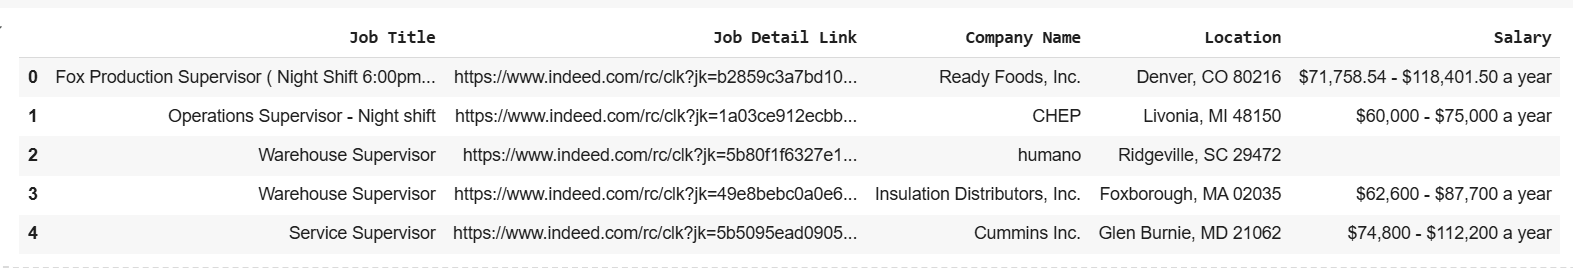

In [12]:
import pandas as pd

# Extract all table rows (excluding the header)
rows = table.find_all("tr")[1:]  # Skip the first row (header)

# Prepare an empty list to store job data
data = []

# Loop through each row and extract job details
for row in rows:
    cells = row.find_all("td")

    job_title = cells[3].get_text(strip=True)
    job_link = cells[4].get_text(strip=True)  # Extract job detail link
    company = cells[6].get_text(strip=True)
    location = cells[7].get_text(strip=True)
    salary = cells[8].get_text(strip=True)

    # Append job details as a dictionary
    data.append({
        "Job Title": job_title,
        "Job Detail Link": job_link,
        "Company Name": company,
        "Location": location,
        "Salary": salary

    })

# Create a DataFrame from the list of job data
df = pd.DataFrame(data)

# Print the DataFrame
df.head()


,Job Title,Job Detail Link,Company Name,Location,Salary
0,Fox Production Supervisor ( Night Shift 6:00pm...,https://www.indeed.com/rc/clk?jk=b2859c3a7bd10...,"Ready Foods, Inc.","Denver, CO 80216","$71,758.54 - $118,401.50 a year"
1,Operations Supervisor - Night shift,https://www.indeed.com/rc/clk?jk=1a03ce912ecbb...,CHEP,"Livonia, MI 48150","$60,000 - $75,000 a year"
2,Warehouse Supervisor,https://www.indeed.com/rc/clk?jk=5b80f1f6327e1...,humano,"Ridgeville, SC 29472",
3,Warehouse Supervisor,https://www.indeed.com/rc/clk?jk=49e8bebc0a0e6...,"Insulation Distributors, Inc.","Foxborough, MA 02035","$62,600 - $87,700 a year"
4,Service Supervisor,https://www.indeed.com/rc/clk?jk=5b5095ead0905...,Cummins Inc.,"Glen Burnie, MD 21062","$74,800 - $112,200 a year"


Problem Statement11:
Now that we have successfully stored all job listings data in a Pandas DataFrame, the next step is to export this data to a CSV file.

Saving job listings in a CSV file will allow us to:
* ✅ Keep a permanent record of job listings.
* ✅ Share the job data with others easily.
* ✅ Use the data for future analysis (e.g., filtering, sorting, and visualization).

1️⃣ Take the existing DataFrame (df) containing job listings.
2️⃣ Save the DataFrame to a CSV file with a meaningful filename.
3️⃣ Ensure the file can be opened and read easily.

Expected Output

✅ Data successfully saved as 'indeed_job_listings.csv'



In [13]:
# Export DataFrame to a CSV file
df.to_csv("indeed_job_listings.csv", index=False)

# Print confirmation message
print("✅ Data successfully saved as 'indeed_job_listings.csv'")


✅ Data successfully saved as 'indeed_job_listings.csv'


Note :  you should download indeed_job_listings.csv and save in the folder so that u can use later

steps to download

Step 1. Open the click on the file icon on the left side of google colab

example image:

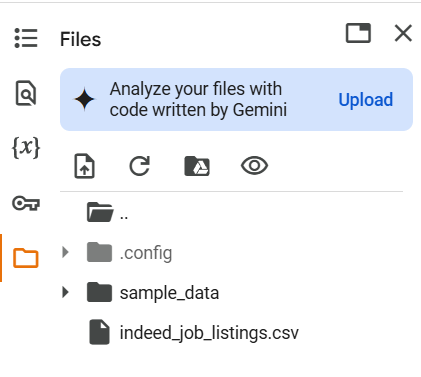

Step 2: when you will click indeed_job_listings.csv you will see three dots  click on that and click on download

